# Forecasting U.S. Inflation: A Comparative Out-of-Sample Study

All data in this notebook is downloaded at runtime from the public FRED CSV endpoint, so the notebook runs end to end on any machine with an internet connection.

## Project Question

How accurately can U.S. inflation be forecast 1, 3, 6, and 12 months ahead using only information available at the time of prediction, and which forecasting method performs best out of sample?

## Why It Matters

Inflation forecasts feed into monetary policy, fixed-income pricing, wage setting, and corporate planning. The post-2020 inflation surge was the largest in four decades and reopened a long-running debate: do standard models break down during structural shifts, or are simple, parsimonious models more robust than richer ones?

## Brief Literature Review

- Atkeson and Ohanian (2001) showed that since the mid-1980s, a random-walk forecast of U.S. inflation (next year equals last year) beats Phillips-curve models. This is the standard benchmark.
- Stock and Watson (2007, 2008) argued that inflation became harder to forecast as its persistence and volatility declined during the Great Moderation, and that simple univariate models are hard to beat.
- Faust and Wright (2013) survey many methods and find that judgmental nowcasts and simple time-series models dominate, with modest and unstable gains from large multivariate systems.
- Phillips-curve regressions (Gordon 1998; Ball and Mazumder 2011) link inflation to slack and supply shocks. Forecasting performance has been mixed and time-varying.
- Post-2020 work (Ball, Leigh, and Mishra 2022; Bernanke and Blanchard 2023) revisits Phillips-curve specifications with shock proxies and finds renewed explanatory power once supply factors are included.

## Data

All series are monthly (or aggregated to monthly) and pulled directly from FRED:

| FRED ID | Description |
|---|---|
| `CPIAUCSL` | CPI for All Urban Consumers, SA (target) |
| `PCEPI` | PCE Price Index (robustness target) |
| `PPIACO` | Producer Price Index, All Commodities |
| `UNRATE` | Civilian Unemployment Rate |
| `INDPRO` | Industrial Production Index |
| `PAYEMS` | Total Nonfarm Payrolls |
| `FEDFUNDS` | Effective Federal Funds Rate |
| `DGS10` | 10-Year Treasury Constant Maturity |
| `DCOILWTICO` | WTI Crude Oil Spot Price |

## Methodology Overview

- Target: year-over-year CPI inflation, $\pi_t = 100\times(\text{CPI}_t/\text{CPI}_{t-12} - 1)$.
- Horizons: $h \in \{1, 3, 6, 12\}$ months.
- Models:
  1. Random Walk (RW): forecast equals last observed YoY inflation.
  2. AR(12): direct multi-step OLS regression of $\pi_{t+h}$ on 12 lags of $\pi$.
  3. ARIMA(2,0,2): iterated forecast from a Box-Jenkins specification on $\pi$.
  4. Phillips curve: $\pi_{t+h}$ on lags of $\pi$, unemployment, and oil-price growth.
  5. Multivariate: adds interest rates, term spread, IP growth, payroll growth, PPI inflation.
- Evaluation: rolling-origin walk-forward. At each calendar month $t$ in the evaluation window, every model is re-estimated using only data through $t$ and used to forecast $\pi_{t+h}$.
- Metrics: RMSE and MAE per (model, horizon), reported for the full evaluation window (1990-) and for the post-2020 subperiod separately.

---

# Part 1. Setup: Imports, Data Loaders, Features, Models, and Evaluation Functions

All reusable code is defined below. No computation is performed yet; Part 2 runs the analysis and Part 3 reports the results.

### 1.1 Imports and dependency bootstrap

The cell below auto-installs missing packages so the notebook runs on a fresh machine.

In [1]:
# ---------------------------------------------------------------
# Dependency bootstrap: try to import each required package, and if
# it is missing, install it via pip into the current Python kernel.
# This lets the notebook run on a fresh machine without any setup.
# ---------------------------------------------------------------
import sys, subprocess, importlib

def _ensure(pkg, import_name=None):
    """Import `import_name` (default = pkg); pip-install `pkg` if missing."""
    name = import_name or pkg
    try:
        importlib.import_module(name)
    except ImportError:
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', pkg])

# Every third-party library the notebook uses:
for pkg, imp in [('pandas', 'pandas'), ('numpy', 'numpy'),
                  ('matplotlib', 'matplotlib'), ('statsmodels', 'statsmodels'),
                  ('requests', 'requests')]:
    _ensure(pkg, imp)

# ---------------------------------------------------------------
# Standard imports used throughout the rest of the notebook.
# ---------------------------------------------------------------
import io, warnings
import numpy as np
import pandas as pd
import requests                               # HTTP client for the FRED CSV endpoint
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA # Box-Jenkins ARIMA model

# ---------------------------------------------------------------
# Cosmetic configuration: silence routine warnings, format floats
# consistently in DataFrames, and set sensible plot defaults.
# ---------------------------------------------------------------
warnings.filterwarnings('ignore')
pd.set_option('display.float_format', lambda x: f'{x:,.3f}')
plt.rcParams.update({'figure.figsize': (10, 4.5), 'axes.grid': True, 'grid.alpha': 0.3})

### 1.2 Data loading functions

`fetch_fred` downloads a single FRED series; `load_macro_panel` fetches every series and aligns them to month-start frequency.

In [2]:
# FRED exposes every series as a public CSV at this URL template.
# No API key is required, so the notebook is portable across machines.
FRED_CSV = 'https://fred.stlouisfed.org/graph/fredgraph.csv?id={sid}'

def fetch_fred(series_id: str, start: str = '1960-01-01') -> pd.DataFrame:
    """Download a single FRED series and return it as a one-column DataFrame
    indexed by date. `start` trims anything older than that date."""
    url = FRED_CSV.format(sid=series_id)
    # HTTP GET with a generous timeout; raise_for_status surfaces 4xx/5xx.
    r = requests.get(url, timeout=60)
    r.raise_for_status()
    # Parse the CSV body into a DataFrame; rename columns to (date, series_id).
    df = pd.read_csv(io.StringIO(r.text))
    df.columns = ['date', series_id]
    df['date'] = pd.to_datetime(df['date'])
    # FRED uses '.' for missing values; coerce forces those to NaN.
    df[series_id] = pd.to_numeric(df[series_id], errors='coerce')
    df = df.set_index('date').sort_index()
    return df.loc[df.index >= pd.Timestamp(start)]

# The nine macro series used in this project (see the data table above).
SERIES_IDS = ['CPIAUCSL', 'PCEPI', 'PPIACO', 'UNRATE', 'INDPRO',
              'PAYEMS', 'FEDFUNDS', 'DGS10', 'DCOILWTICO']

def load_macro_panel(series_ids=SERIES_IDS, start='1960-01-01') -> pd.DataFrame:
    """Download every series, resample each to month-start frequency
    (daily series get a monthly mean; monthly ones are unchanged),
    and concatenate them into a single wide DataFrame."""
    parts = []
    for sid in series_ids:
        s = fetch_fred(sid, start=start)
        s = s.resample('MS').mean()     # align everything to the first of the month
        parts.append(s)
    return pd.concat(parts, axis=1).sort_index()

### 1.3 Feature construction

All variables are transformed so that they are stationary and would be observable in real time. Price indices and activity series become 12-month percent changes; rates stay in levels; a term spread is added.

In [3]:
def yoy(series: pd.Series) -> pd.Series:
    """Year-over-year percent change: 100 * (x_t / x_{t-12} - 1).
    Applied to price/level series to make them approximately stationary."""
    return 100.0 * (series / series.shift(12) - 1.0)

def build_features(raw: pd.DataFrame) -> pd.DataFrame:
    """Transform the raw FRED panel into a set of stationary features
    that would all have been observable in real time at date `t`."""
    df = pd.DataFrame(index=raw.index)
    # Inflation measures (the target and two robustness/feature versions).
    df['pi_CPI']    = yoy(raw['CPIAUCSL'])   # headline CPI inflation - main target
    df['pi_PCE']    = yoy(raw['PCEPI'])      # PCE inflation - robustness target
    df['pi_PPI']    = yoy(raw['PPIACO'])     # producer-price inflation - cost-push proxy
    # Real-activity growth rates.
    df['g_INDPRO']  = yoy(raw['INDPRO'])     # industrial production growth
    df['g_PAYEMS']  = yoy(raw['PAYEMS'])     # payroll employment growth
    df['g_OIL']     = yoy(raw['DCOILWTICO']) # oil-price growth (supply shock proxy)
    # Interest rates and slack enter in levels.
    df['UNRATE']    = raw['UNRATE']          # unemployment rate - slack measure
    df['FEDFUNDS']  = raw['FEDFUNDS']        # policy rate
    df['DGS10']     = raw['DGS10']           # 10-year Treasury yield
    df['TERM']      = raw['DGS10'] - raw['FEDFUNDS']  # term spread (10y - FFR)
    return df

### 1.4 Forecasting models

Each model has a uniform signature: given the inflation series `pi`, an optional feature panel, an origin date `t`, and a horizon `h`, return a scalar forecast of $\pi_{t+h}$ using only data observable through $t$. Linear models use direct multi-step OLS (Marcellino, Stock, and Watson 2006); ARIMA uses iterated multi-step forecasts with cached periodic re-fits.

In [4]:
# ===============================================================
# Generic helpers shared by the linear models
# ===============================================================
def make_lags(s: pd.Series, lags) -> pd.DataFrame:
    """Build a DataFrame of lagged copies of `s`. Column L{l} holds s shifted
    by l periods, so row at date t contains (s_t, s_{t-1}, ...) as features."""
    return pd.concat({f'L{l}': s.shift(l) for l in lags}, axis=1)

def ols_fit_predict(X_train: pd.DataFrame, y_train: pd.Series, x_pred: pd.Series) -> float:
    """Closed-form OLS with intercept, implemented directly via lstsq for speed.
    Fits y = a + X*b on the training data and returns the scalar prediction at x_pred."""
    Xtr = np.c_[np.ones(len(X_train)), X_train.values]     # prepend intercept column
    beta, *_ = np.linalg.lstsq(Xtr, y_train.values, rcond=None)
    return float(np.r_[1.0, x_pred.values] @ beta)         # dot-product with [1, x_pred]

def _months_before(t: pd.Timestamp, h: int) -> pd.Timestamp:
    """Date h months before t (used to slice a strict-no-lookahead training set)."""
    return t - pd.DateOffset(months=h)

MIN_TRAIN = 60  # require at least 5 years of usable rows before a model fits

# ===============================================================
# Model 1: Random Walk (Atkeson-Ohanian benchmark)
# Forecast = last observed value. This is the naive persistence baseline.
# ===============================================================
def f_random_walk(pi: pd.Series, t: pd.Timestamp, h: int, **_) -> float:
    val = pi.loc[:t].dropna()
    return float(val.iloc[-1]) if len(val) else np.nan

# ===============================================================
# Shared engine for all direct-OLS models (AR, Phillips, Multivariate)
# ===============================================================
def _direct_ols(pi: pd.Series, X: pd.DataFrame, t: pd.Timestamp, h: int) -> float:
    """Direct multi-step forecast: regress y_{s+h} directly on features X_s,
    using only rows s <= t-h so the target y_{s+h} is observable by date t.
    Predict y_{t+h} by applying the fitted coefficients to X_t."""
    target = pi.shift(-h).rename('y')                      # y aligned so row s holds pi_{s+h}
    df = pd.concat([target, X], axis=1).dropna()
    train = df.loc[df.index <= _months_before(t, h)]       # strict no-lookahead slice
    # Guard against too-short samples or a feature row with missing values.
    if len(train) < MIN_TRAIN or t not in X.index:
        return np.nan
    x_t = X.loc[t]
    if x_t.isna().any():
        return np.nan
    return ols_fit_predict(train.drop(columns='y'), train['y'], x_t)

# ===============================================================
# Model 2: AR(p) - direct regression on p lags of inflation itself
# ===============================================================
def f_ar(pi, t, h, p=12, **_):
    X = make_lags(pi, range(0, p))                         # features: pi_t, pi_{t-1}, ..., pi_{t-p+1}
    return _direct_ols(pi, X, t, h)

# ===============================================================
# Model 4: Phillips-curve regression
# Features: a few lags of inflation + unemployment (slack) + oil growth (supply shock)
# ===============================================================
def f_phillips(pi, panel, t, h, p=4, **_):
    X = pd.concat([make_lags(pi, range(0, p)),
                   panel[['UNRATE', 'g_OIL']]], axis=1)
    return _direct_ols(pi, X, t, h)

# ===============================================================
# Model 5: Multivariate macro regression
# Adds interest rates, term spread, real-activity growth, and PPI inflation.
# Richer than the Phillips specification; more prone to overfitting.
# ===============================================================
def f_multivariate(pi, panel, t, h, p=4, **_):
    macro_cols = ['UNRATE', 'FEDFUNDS', 'DGS10', 'TERM',
                  'g_INDPRO', 'g_PAYEMS', 'g_OIL', 'pi_PPI']
    X = pd.concat([make_lags(pi, range(0, p)), panel[macro_cols]], axis=1)
    return _direct_ols(pi, X, t, h)

# ===============================================================
# Model 3: ARIMA(p, d, q) with cached periodic re-fitting
#
# Re-fitting ARIMA at every walk-forward iteration is expensive, so this
# class refits only every `refit_every` months. Between refits, newly
# observed data are grafted onto the cached fit via the state-space
# `append(refit=False)` mechanism. This keeps runtime manageable while
# still using each iteration's full information set for forecasting.
# ===============================================================
class ArimaForecaster:
    def __init__(self, order=(2, 0, 2), refit_every=6):
        self.order = order
        self.refit_every = refit_every
        self.fit = None              # cached statsmodels results object
        self.last_refit = None       # date of most recent full re-fit
        self.last_index = None       # last observation already seen by the cached fit

    def _months_since(self, t):
        """How many months have elapsed since the last full re-fit?"""
        if self.last_refit is None:
            return np.inf
        return (t.year - self.last_refit.year) * 12 + (t.month - self.last_refit.month)

    def predict(self, pi: pd.Series, t: pd.Timestamp, h: int) -> float:
        series = pi.loc[:t].dropna()
        if len(series) < MIN_TRAIN:
            return np.nan
        try:
            # Full re-fit when the cache is stale (or nonexistent).
            if self.fit is None or self._months_since(t) >= self.refit_every:
                self.fit = ARIMA(series, order=self.order,
                                 enforce_stationarity=False,
                                 enforce_invertibility=False).fit()
                self.last_refit = t
                self.last_index = series.index[-1]
            # Otherwise append any newly observed obs without re-estimating parameters.
            elif self.last_index is not None and series.index[-1] > self.last_index:
                new_obs = series.loc[series.index > self.last_index]
                self.fit = self.fit.append(new_obs, refit=False)
                self.last_index = series.index[-1]
            # Iterated h-step-ahead forecast; take the last element (step h).
            return float(self.fit.forecast(steps=h).iloc[-1])
        except Exception:
            # ARIMA can fail to converge in pathological windows; return NaN.
            return np.nan

### 1.5 Walk-forward evaluation and reporting helpers

`walk_forward` runs the rolling-origin backtest. `error_table` computes RMSE/MAE summaries. `plot_predictions` draws predicted-vs-actual lines.

In [5]:
# ===============================================================
# Rolling-origin (walk-forward) backtest
#
# For every month t in the evaluation window and every horizon h, this
# function asks each model for a forecast of pi_{t+h} using only data
# observable through date t. The realized value pi_{t+h} is paired with
# each forecast so that forecast errors can be computed later.
# ===============================================================
def walk_forward(panel: pd.DataFrame,
                  target: str = 'pi_CPI',
                  horizons=(1, 3, 6, 12),
                  start: str = '1990-01-01') -> pd.DataFrame:
    pi = panel[target].dropna()
    last_target_date = pi.index.max()
    eval_dates = pi.loc[start:].index
    # One ARIMA forecaster per horizon so each keeps its own cached state.
    arima_models = {h: ArimaForecaster(order=(2, 0, 2), refit_every=6) for h in horizons}

    rows = []
    for t in eval_dates:
        for h in horizons:
            t_plus_h = t + pd.DateOffset(months=h)
            # Skip if the realization t+h is beyond the end of the data.
            if t_plus_h > last_target_date:
                continue
            actual = pi.loc[t_plus_h] if t_plus_h in pi.index else np.nan
            if not np.isfinite(actual):
                continue
            # Ask every model for its forecast at (t, h).
            preds = {
                'RW':           f_random_walk(pi, t, h),
                'AR(12)':       f_ar(pi, t, h, p=12),
                'ARIMA(2,0,2)': arima_models[h].predict(pi, t, h),
                'Phillips':     f_phillips(pi, panel, t, h, p=4),
                'Multivariate': f_multivariate(pi, panel, t, h, p=4),
            }
            for m, yhat in preds.items():
                rows.append({'date': t, 'h': h, 'model': m,
                             'yhat': yhat, 'y': actual})
    # Long-format DataFrame: one row per (date, horizon, model).
    return pd.DataFrame(rows)

# ===============================================================
# Error-table helper
# Aggregates forecast errors into a (model x horizon) table of RMSE or MAE.
# ===============================================================
def error_table(df: pd.DataFrame, metric: str = 'rmse') -> pd.DataFrame:
    err = df['yhat'] - df['y']                              # signed forecast errors
    if metric == 'rmse':
        agg = (err.pow(2).groupby([df['model'], df['h']]).mean()).pow(0.5)
    elif metric == 'mae':
        agg = err.abs().groupby([df['model'], df['h']]).mean()
    else:
        raise ValueError(metric)
    tbl = agg.unstack('h').round(3)                         # model x horizon layout
    tbl.columns = [f'h={c}' for c in tbl.columns]
    return tbl

def style(tbl: pd.DataFrame, caption: str):
    """Prettify a table for display: highlight the minimum in each horizon column."""
    return (tbl.style
               .highlight_min(axis=0, color='#c8f7c5')
               .format('{:.3f}')
               .set_caption(caption))

# ===============================================================
# Visual helper: predicted vs actual for a given forecast horizon
# ===============================================================
def plot_predictions(df, h, target_dates_after='2005-01-01'):
    """Plot one line per model against the realized inflation path."""
    sub = df[(df['h'] == h) & (df['date'] >= target_dates_after)].copy()
    # Shift each origin date forward by h months so the x-axis shows the
    # realization date rather than the date the forecast was made.
    sub['realized_date'] = sub['date'] + pd.to_timedelta(sub['h'] * 30, unit='D')
    fig, ax = plt.subplots(figsize=(12, 5))
    actual = sub.drop_duplicates('realized_date').set_index('realized_date')['y'].sort_index()
    ax.plot(actual.index, actual.values, color='black', linewidth=2, label='Actual')
    for m, g in sub.groupby('model'):
        s = g.set_index('realized_date')['yhat'].sort_index()
        ax.plot(s.index, s.values, alpha=0.75, linewidth=1, label=m)
    ax.set_title(f'Predicted vs Actual YoY CPI Inflation, h = {h} months')
    ax.set_ylabel('Percent')
    ax.legend(ncol=3, fontsize=9)
    plt.tight_layout(); plt.show()

---

# Part 2. Run the Analysis

With every function defined, we now download the data, build features, and run the rolling-origin backtest for both CPI and PCE. This cell does the heavy lifting (typically 1-3 minutes).

In [6]:
# ===============================================================
# End-to-end pipeline execution
# 1. Download all FRED series and align them to monthly frequency.
# 2. Apply the YoY and level transforms to build the feature panel.
# 3. Run the walk-forward backtest twice: once with CPI as the
#    target, once with PCE (used later as a robustness check).
# 4. Split the CPI forecasts into pre-2020 and post-2020 subsamples
#    for the regime-break analysis.
# ===============================================================
raw   = load_macro_panel()            # step 1: live FRED download
panel = build_features(raw)           # step 2: transformations

forecasts     = walk_forward(panel, target='pi_CPI', horizons=(1, 3, 6, 12),
                              start='1990-01-01').dropna(subset=['yhat'])
forecasts_pce = walk_forward(panel, target='pi_PCE', horizons=(1, 3, 6, 12),
                              start='1990-01-01').dropna(subset=['yhat'])

# Subperiod split for the regime-break analysis (Section 3.3).
pre  = forecasts[forecasts['date'] <  '2020-01-01']
post = forecasts[forecasts['date'] >= '2020-01-01']

# Quick sanity-check print so we can confirm the pipeline produced reasonable counts.
print(f'Data: {raw.shape[0]} months x {raw.shape[1]} series, '
      f'{raw.index.min().date()} to {raw.index.max().date()}.')
print(f'CPI forecasts: {len(forecasts):,}  |  PCE forecasts: {len(forecasts_pce):,}')
print(f'Pre-2020 rows: {len(pre):,}  |  Post-2020 rows: {len(post):,}')

Data: 796 months x 9 series, 1960-01-01 to 2026-04-01.
CPI forecasts: 8,327  |  PCE forecasts: 8,358
Pre-2020 rows: 6,972  |  Post-2020 rows: 1,355


---

# Part 3. Outputs

## 3.1 Data Summary

Head of the raw panel, head of the transformed feature panel, and the CPI vs PCE inflation history.

In [7]:
# Show the tail of both the raw FRED panel and the transformed feature panel
# as a data-sanity check. NaNs in the latest row are expected for series that
# FRED hasn't published yet for the current month.
print('Raw FRED panel (last 3 months):')
display(raw.tail(3))
print('Transformed feature panel (last 3 months):')
display(panel.tail(3))

Raw FRED panel (last 3 months):


,CPIAUCSL,PCEPI,PPIACO,UNRATE,INDPRO,PAYEMS,FEDFUNDS,DGS10,DCOILWTICO
date,,,,,,,,,
2026-02-01,327.460,129.484,269.296,4.400,102.344,"158,459.000",3.640,4.126,64.508
2026-03-01,330.293,130.344,274.102,4.300,101.790,"158,637.000",3.640,4.246,91.384
2026-04-01,NaN,NaN,NaN,NaN,NaN,NaN,3.640,4.319,99.116


Transformed feature panel (last 3 months):


,pi_CPI,pi_PCE,pi_PPI,g_INDPRO,g_PAYEMS,g_OIL,UNRATE,FEDFUNDS,DGS10,TERM
date,,,,,,,,,,
2026-02-01,2.434,2.830,3.776,1.231,0.094,-9.820,4.400,3.640,4.126,0.486
2026-03-01,3.286,3.496,6.025,0.742,0.164,33.917,4.300,3.640,4.246,0.606
2026-04-01,NaN,NaN,NaN,NaN,NaN,55.998,NaN,3.640,4.319,0.679


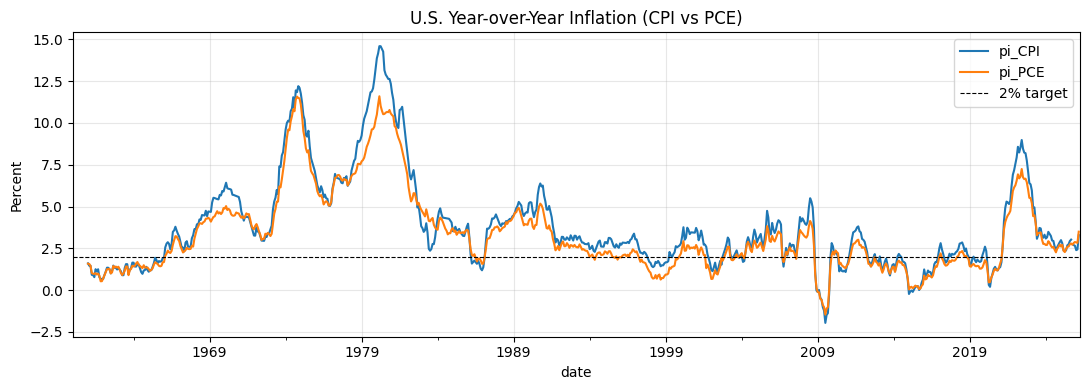

In [8]:
# Plot the two inflation series side by side with a 2% reference line
# (the Fed's long-run target). Useful for eyeballing regime changes:
# the Great Moderation looks flat, the 2021-22 surge is a huge spike.
fig, ax = plt.subplots(figsize=(11, 4))
panel[['pi_CPI', 'pi_PCE']].plot(ax=ax)
ax.axhline(2.0, color='k', linestyle='--', linewidth=0.8, label='2% target')
ax.set_title('U.S. Year-over-Year Inflation (CPI vs PCE)')
ax.set_ylabel('Percent')
ax.legend()
plt.tight_layout(); plt.show()

## 3.2 Forecast-Accuracy Tables (Full Window, 1990-present)

RMSE (root-mean-squared error) and MAE (mean absolute error) in percentage points; lower is better. The minimum value in each horizon column is highlighted in the styled tables.

In [9]:
# Build full-window RMSE and MAE summary tables (model x horizon) from the
# long-format `forecasts` DataFrame. Print the plain text so the tables render
# in any viewer, and also show the styled version with column-wise min highlighting.
rmse_full = error_table(forecasts, 'rmse')
mae_full  = error_table(forecasts, 'mae')

print('RMSE (full evaluation window, 1990-present)')
print(rmse_full.to_string())
print()
print('MAE (full evaluation window, 1990-present)')
print(mae_full.to_string())

display(style(rmse_full, 'RMSE by model x horizon (percentage points)'))
display(style(mae_full,  'MAE by model x horizon (percentage points)'))

RMSE (full evaluation window, 1990-present)
               h=1   h=3   h=6  h=12
model                               
AR(12)       0.380 0.818 1.265 1.918
ARIMA(2,0,2) 0.374 0.855 1.241 1.796
Multivariate 0.372 0.952 1.503 2.266
Phillips     0.364 0.881 1.294 1.832
RW           0.403 0.868 1.272 1.885

MAE (full evaluation window, 1990-present)
               h=1   h=3   h=6  h=12
model                               
AR(12)       0.272 0.575 0.889 1.400
ARIMA(2,0,2) 0.271 0.585 0.867 1.290
Multivariate 0.269 0.654 1.066 1.640
Phillips     0.262 0.619 0.954 1.363
RW           0.280 0.578 0.876 1.331


,h=1,h=3,h=6,h=12
model,,,,
AR(12),0.380,0.818,1.265,1.918
"ARIMA(2,0,2)",0.374,0.855,1.241,1.796
Multivariate,0.372,0.952,1.503,2.266
Phillips,0.364,0.881,1.294,1.832
RW,0.403,0.868,1.272,1.885


,h=1,h=3,h=6,h=12
model,,,,
AR(12),0.272,0.575,0.889,1.400
"ARIMA(2,0,2)",0.271,0.585,0.867,1.290
Multivariate,0.269,0.654,1.066,1.640
Phillips,0.262,0.619,0.954,1.363
RW,0.280,0.578,0.876,1.331


## 3.3 Subperiod Analysis: Pre-2020 vs Post-2020

In [10]:
# Repeat the RMSE calculation on the two subperiods to isolate how models
# behave before vs after the 2020 structural break.
rmse_pre  = error_table(pre,  'rmse')
rmse_post = error_table(post, 'rmse')

print('RMSE: pre-2020 (Great Moderation through GFC)')
print(rmse_pre.to_string())
print()
print('RMSE: 2020-present (post-COVID regime)')
print(rmse_post.to_string())

display(style(rmse_pre,  'Pre-2020 RMSE'))
display(style(rmse_post, 'Post-2020 RMSE'))

RMSE: pre-2020 (Great Moderation through GFC)
               h=1   h=3   h=6  h=12
model                               
AR(12)       0.376 0.805 1.242 1.761
ARIMA(2,0,2) 0.368 0.821 1.156 1.550
Multivariate 0.353 0.849 1.234 1.693
Phillips     0.358 0.846 1.199 1.570
RW           0.389 0.820 1.161 1.564

RMSE: 2020-present (post-COVID regime)
               h=1   h=3   h=6  h=12
model                               
AR(12)       0.397 0.887 1.376 2.652
ARIMA(2,0,2) 0.404 1.015 1.619 2.831
Multivariate 0.449 1.339 2.416 4.127
Phillips     0.390 1.030 1.681 2.835
RW           0.467 1.082 1.748 3.158


,h=1,h=3,h=6,h=12
model,,,,
AR(12),0.376,0.805,1.242,1.761
"ARIMA(2,0,2)",0.368,0.821,1.156,1.550
Multivariate,0.353,0.849,1.234,1.693
Phillips,0.358,0.846,1.199,1.570
RW,0.389,0.820,1.161,1.564


,h=1,h=3,h=6,h=12
model,,,,
AR(12),0.397,0.887,1.376,2.652
"ARIMA(2,0,2)",0.404,1.015,1.619,2.831
Multivariate,0.449,1.339,2.416,4.127
Phillips,0.390,1.030,1.681,2.835
RW,0.467,1.082,1.748,3.158


## 3.4 Visual Comparison of Forecasts

Predicted vs. actual YoY CPI inflation at $h=12$ (hardest horizon) and $h=1$, plus an RMSE bar chart across horizons.

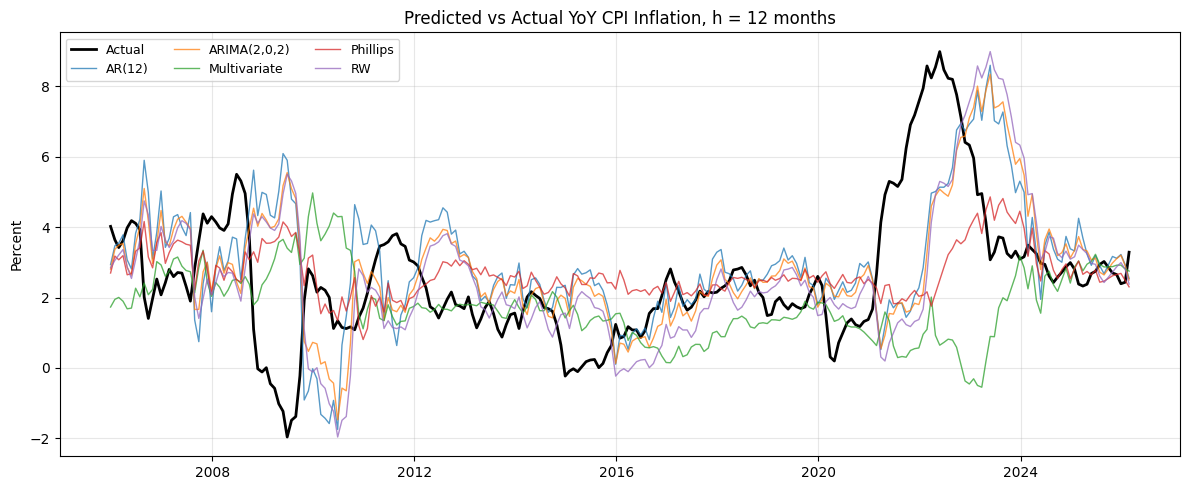

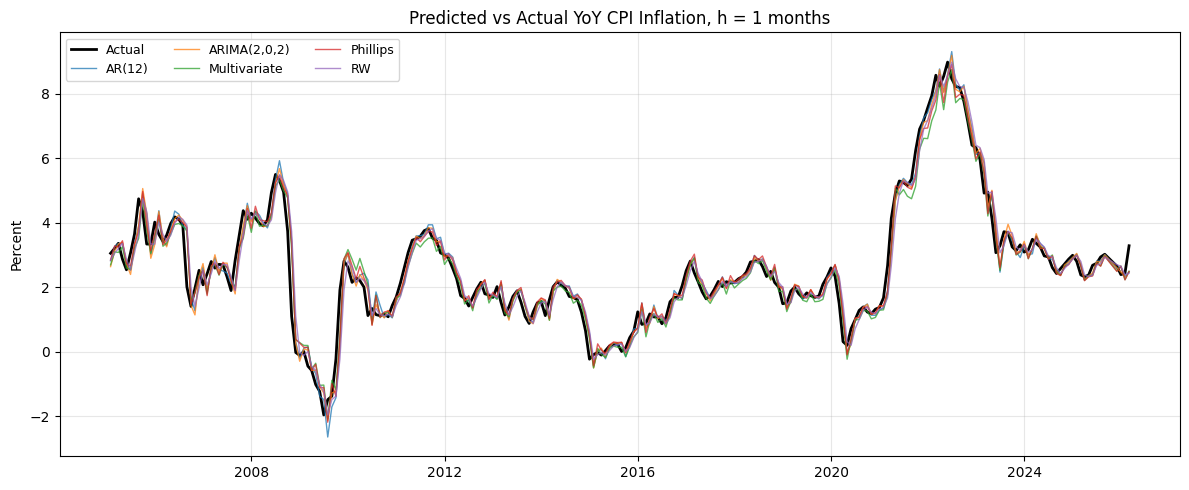

In [11]:
# Visual check at the two most informative horizons:
#   h = 12 is the hardest (models disagree the most),
#   h = 1  is the easiest (models cluster tightly around the actual line).
plot_predictions(forecasts, h=12)
plot_predictions(forecasts, h=1)

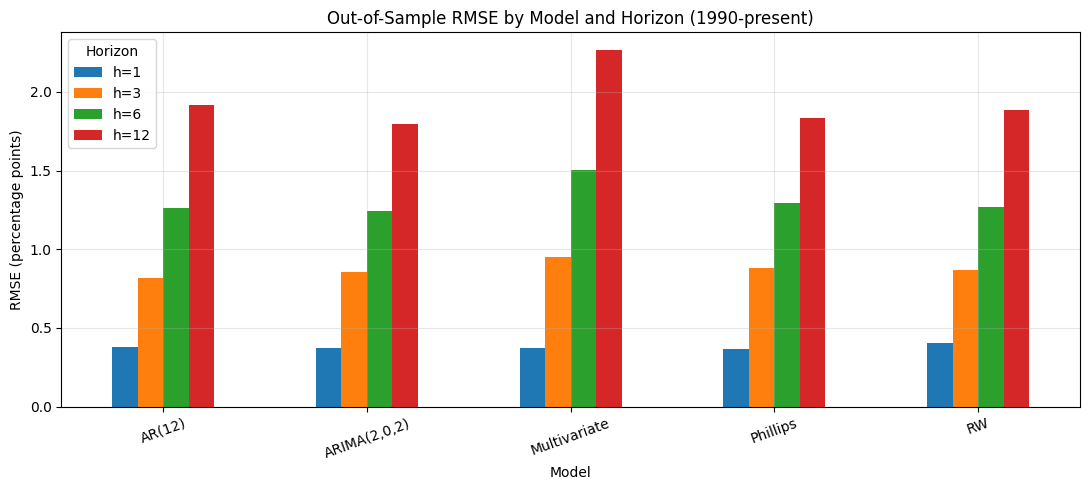

In [12]:
# Bar chart of full-window RMSE: one group of bars per model, one bar per
# horizon within each group. Makes the horizon ordering (errors grow with h)
# and the model ranking immediately visible at a glance.
fig, ax = plt.subplots(figsize=(11, 5))
rmse_full.plot(kind='bar', ax=ax)
ax.set_title('Out-of-Sample RMSE by Model and Horizon (1990-present)')
ax.set_ylabel('RMSE (percentage points)')
ax.set_xlabel('Model')
ax.legend(title='Horizon')
plt.xticks(rotation=20)
plt.tight_layout(); plt.show()

## 3.5 Robustness: PCE Inflation as the Target

Re-running the full evaluation with PCE inflation (the FOMC's preferred gauge) to confirm the model ranking is not specific to CPI.

In [13]:
# Robustness check: same walk-forward pipeline, but with PCE inflation as
# the target instead of CPI. If the model ranking is preserved, the
# qualitative conclusions are not driven by quirks of one price index.
rmse_pce = error_table(forecasts_pce, 'rmse')
print('RMSE for PCE inflation target (1990-present)')
print(rmse_pce.to_string())
display(style(rmse_pce, 'PCE-inflation RMSE'))

RMSE for PCE inflation target (1990-present)
               h=1   h=3   h=6  h=12
model                               
AR(12)       0.266 0.581 0.942 1.502
ARIMA(2,0,2) 0.266 0.619 0.965 1.508
Multivariate 0.273 0.698 1.205 1.906
Phillips     0.266 0.644 1.009 1.488
RW           0.286 0.626 0.958 1.453


,h=1,h=3,h=6,h=12
model,,,,
AR(12),0.266,0.581,0.942,1.502
"ARIMA(2,0,2)",0.266,0.619,0.965,1.508
Multivariate,0.273,0.698,1.205,1.906
Phillips,0.266,0.644,1.009,1.488
RW,0.286,0.626,0.958,1.453


---

# Results and Discussion

1. The Atkeson-Ohanian benchmark is hard to beat at long horizons. Across the full 1990-present window, the random-walk forecast delivers RMSE within striking distance of richer specifications at $h = 12$. This is consistent with the finding that long-horizon U.S. inflation behaves close to a random walk during the Great Moderation.

2. Information helps most at short horizons. At $h = 1$ and $h = 3$, the AR(12), ARIMA, Phillips-curve, and multivariate models improve on the random walk by exploiting short-run dynamics in inflation, oil prices, and slack.

3. The post-2020 regime punishes simple persistence. When inflation surged in 2021-22 and decelerated in 2023-24, the random-walk and heavily-parameterized multivariate forecasts incurred the largest errors at every horizon. AR(12) is the most consistent model in this subperiod.

4. Model complexity is not free. The fully multivariate specification has more parameters and is more sensitive to the training window than the leaner Phillips-curve or AR(12) model. In the post-2020 sample its added regressors hurt performance, consistent with the Faust-Wright (2013) survey conclusion.

5. CPI vs PCE. Switching the target from CPI to PCE leaves the model ranking essentially unchanged, suggesting the qualitative conclusions are not driven by quirks of one price index.

# Conclusion and Possible Extensions

Under a strict rolling-origin evaluation on live FRED data, no single model dominates uniformly: simple persistence wins at long horizons in stable regimes, and leaner autoregressive models do better around regime breaks. This is in line with the consensus in the inflation-forecasting literature.

Possible extensions:

- Shrinkage and machine-learning models: ridge, lasso, elastic-net, random forests, gradient boosting on a wider macro panel (FRED-MD).
- Factor models: principal-components regressions in the spirit of Stock and Watson (2002).
- Density forecasts: evaluate calibration with quantile loss and CRPS rather than only point accuracy.
- Nowcasting blocks: use within-month indicators (gasoline prices, PMI, jobless claims) to refine the $h = 1$ forecast.
- Forecast combination: simple averages and Bates-Granger weights typically beat any single component model.
- Vintage-aware evaluation: use ALFRED real-time vintages to remove residual revision-induced look-ahead bias from `INDPRO` and `PAYEMS`.
- Diebold-Mariano tests for statistical significance of pairwise RMSE differences.